In [ ]:
#------------------Imports---------------------
#most common libraries
import os, json, math, random, pathlib, gc
from dataclasses import dataclass, asdict
from typing import List, Dict, Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# signal processing libraries for EEG data analysis
import scipy.signal as sig
from scipy.stats import skew, kurtosis

# ml libs for training and eval
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

#PyTorch -- mabye?
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
# Mount Google Drive to access files stored there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# List the contents of the specified Google Drive folder to confirm the zip file exists
!ls "/content/drive/Shareddrives/BioRobotics Final Project/Data"

# Define the path to the zip file containing EEG project data
zip_path = "/content/drive/Shareddrives/BioRobotics Final Project/Data/EEG_Project_Data.zip"

'EEG_Project_Data(old).zip'   EEG_Project_Data.zip
 EEG_Project_Data_Trimmed     trim_summary.csv


In [ ]:
import zipfile
import os
import shutil

# path to the zip file and dir for extraction
zip_path = "/content/drive/Shareddrives/BioRobotics Final Project/Data/EEG_Project_Data.zip"
extract_path = "/content/EEG_data"

# If the extraction directory already exists remove it for clean extract
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

#Create new extraction directoy
os.makedirs(extract_path, exist_ok=True)

# Extract the contents to the path
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Fresh unzip complete.")

Fresh unzip complete.


In [ ]:
# Recursively list the contents of the extracted EEG data directory to inspect its structure
!ls -R /content/EEG_data | head -100

/content/EEG_data:
Christian
Coop
Marinna
Paul

/content/EEG_data/Christian:
rest
Semi
Stimulated

/content/EEG_data/Christian/rest:
trial003_Unicorn_EEG_20260420_160803.csv

/content/EEG_data/Christian/Semi:
trial002_Unicorn_EEG_20260420_155058.csv

/content/EEG_data/Christian/Stimulated:
trial001_Unicorn_EEG_20260420_153404.csv

/content/EEG_data/Coop:
rest
Semi
Stimulated

/content/EEG_data/Coop/rest:
trial001_Unicorn_EEG_20260406_182344.csv

/content/EEG_data/Coop/Semi:
trial001_Unicorn_EEG_20260406_180604.csv

/content/EEG_data/Coop/Stimulated:
trial001_Unicorn_EEG_20260406_174638.csv

/content/EEG_data/Marinna:
rest
Semi
Stimulated

/content/EEG_data/Marinna/rest:
trial003_Unicorn_EEG_20260418_175837.csv

/content/EEG_data/Marinna/Semi:
trial002_Unicorn_EEG_20260418_174002.csv

/content/EEG_data/Marinna/Stimulated:
trial001_Unicorn_EEG_20260418_172146.csv

/content/EEG_data/Paul:
rest
Semi
Stimulated
test

/content/EEG_data/Paul/rest:
trial003_Unicorn_EEG_20260406_165520.csv

/co

In [ ]:
#Reimport if running just this cell
import os
import pandas as pd

# Base path where the EEG data is extracted
base_path = "/content/EEG_data"

# Map dictionary for the raw classes to standardized class names and labels
class_map = {
    "Stimulated": {"class_name": "stimulated", "label": 2},
    "Semi": {"class_name": "mid", "label": 1},
    "rest": {"class_name": "drowsy", "label": 0},
}

rows = []

#iterate through subjects, the raw classes, and files to collect metadata
for subject in os.listdir(base_path):
    subject_path = os.path.join(base_path, subject)
    if not os.path.isdir(subject_path):
        continue

    for raw_class in os.listdir(subject_path):
        class_path = os.path.join(subject_path, raw_class)
        if not os.path.isdir(class_path):
            continue

        #Skip the extra Paul folder lol
        if raw_class not in class_map:
            print(f"Skipping unknown folder: {class_path}")
            continue

        for fname in os.listdir(class_path):
            if fname.endswith(".csv"):
                fpath = os.path.join(class_path, fname)
                rows.append({
                    "subject": subject,
                    "raw_class": raw_class,
                    "class_name": class_map[raw_class]["class_name"],
                    "label": class_map[raw_class]["label"],
                    "filepath": fpath,
                    "filename": fname
                })

# Create a Pandas DataFrame from the collected metadata
df_meta = pd.DataFrame(rows)

# Sort the DataFrame for consistent order and reset the index
df_meta = df_meta.sort_values(["subject", "label"]).reset_index(drop=True)

# Print the metadata DataFrame and counts by subject/class
print(df_meta)
print("\nCounts by subject/class:")
print(df_meta.groupby(["subject", "class_name"]).size())

Skipping unknown folder: /content/EEG_data/Paul/test
      subject   raw_class  class_name  label  \
0   Christian        rest      drowsy      0   
1   Christian        Semi         mid      1   
2   Christian  Stimulated  stimulated      2   
3        Coop        rest      drowsy      0   
4        Coop        Semi         mid      1   
5        Coop  Stimulated  stimulated      2   
6     Marinna        rest      drowsy      0   
7     Marinna        Semi         mid      1   
8     Marinna  Stimulated  stimulated      2   
9        Paul        rest      drowsy      0   
10       Paul        Semi         mid      1   
11       Paul  Stimulated  stimulated      2   

                                             filepath  \
0   /content/EEG_data/Christian/rest/trial003_Unic...   
1   /content/EEG_data/Christian/Semi/trial002_Unic...   
2   /content/EEG_data/Christian/Stimulated/trial00...   
3   /content/EEG_data/Coop/rest/trial001_Unicorn_E...   
4   /content/EEG_data/Coop/Semi/trial

In [ ]:
# Save the generated metadata DataFrame to a CSV file
df_meta.to_csv("/content/eeg_metadata.csv", index=False)
print("Saved metadata to /content/eeg_metadata.csv")

Saved metadata to /content/eeg_metadata.csv


In [ ]:
# This section creates Leave-One-Subject-Out (LOSO) cross-validation splits
# This is a common strategy to ensure model generalization across different subjects.

# Get unique subject names from the metadata DataFrame
subjects = df_meta["subject"].unique()

loso_splits = []

# Iterate through each subject to create a split where one subject is the test set
for test_subject in subjects:
    # Training data includes all subjects except the current test_subject
    train_df = df_meta[df_meta["subject"] != test_subject].reset_index(drop=True)
    # Test data includes only the current test_subject
    test_df = df_meta[df_meta["subject"] == test_subject].reset_index(drop=True)

    # Store the split information in a list
    loso_splits.append({
        "test_subject": test_subject,
        "train_df": train_df,
        "test_df": test_df
    })

# Print details of each LOSO split to verify correctness
for split in loso_splits:
    print(f"\nLOSO split: test on {split['test_subject']}")
    print("Train subjects:", split["train_df"]["subject"].unique())
    print("Test subjects:", split["test_df"]["subject"].unique())
    print("Train counts:")
    print(split["train_df"].groupby(["subject", "class_name"]).size())
    print("Test counts:")
    print(split["test_df"].groupby(["subject", "class_name"]).size())


LOSO split: test on Christian
Train subjects: ['Coop' 'Marinna' 'Paul']
Test subjects: ['Christian']
Train counts:
subject  class_name
Coop     drowsy        1
         mid           1
         stimulated    1
Marinna  drowsy        1
         mid           1
         stimulated    1
Paul     drowsy        1
         mid           1
         stimulated    1
dtype: int64
Test counts:
subject    class_name
Christian  drowsy        1
           mid           1
           stimulated    1
dtype: int64

LOSO split: test on Coop
Train subjects: ['Christian' 'Marinna' 'Paul']
Test subjects: ['Coop']
Train counts:
subject    class_name
Christian  drowsy        1
           mid           1
           stimulated    1
Marinna    drowsy        1
           mid           1
           stimulated    1
Paul       drowsy        1
           mid           1
           stimulated    1
dtype: int64
Test counts:
subject  class_name
Coop     drowsy        1
         mid           1
         stimulated    1


In [ ]:
# Check the lengths of all EEG recording files to determine the shortest length for truncation
import os
import pandas as pd

# Define the base path for EEG data
base_path = "/content/EEG_data"

# Mapping for raw class names to standardized class names
class_map = {
    "rest": "drowsy",
    "Semi": "mid",
    "Stimulated": "stimulated",
}

rows = []
bad_files = []

# Function to safely read CSV files, ignoring comment lines starting with '#'
def safe_read_csv(fpath):
    return pd.read_csv(fpath, comment="#")

# Iterate through subjects, raw classes, and files to get file lengths
for subject in os.listdir(base_path):
    subject_path = os.path.join(base_path, subject)
    if not os.path.isdir(subject_path):
        continue

    for raw_class in os.listdir(subject_path):
        class_path = os.path.join(subject_path, raw_class)
        if not os.path.isdir(class_path):
            continue

        # Skip unknown folders
        if raw_class not in class_map:
            continue

        for fname in os.listdir(class_path):
            if fname.endswith(".csv"):
                fpath = os.path.join(class_path, fname)
                try:
                    # Read each CSV and record its number of samples
                    df = safe_read_csv(fpath)
                    rows.append({
                        "subject": subject,
                        "raw_class": raw_class,
                        "class_name": class_map[raw_class],
                        "filename": fname,
                        "filepath": fpath,
                        "n_samples": len(df)
                    })
                except Exception as e:
                    # If there's an error reading a file, log it
                    bad_files.append({
                        "subject": subject,
                        "raw_class": raw_class,
                        "filename": fname,
                        "filepath": fpath,
                        "error": str(e)
                    })

# Create DataFrames for file lengths and any bad files
length_df = pd.DataFrame(rows).sort_values(["subject", "class_name"]).reset_index(drop=True)
bad_df = pd.DataFrame(bad_files)

# Print file lengths summary
print(length_df[["subject", "class_name", "filename", "n_samples"]])
print("\nMinimum length:", length_df["n_samples"].min())
print("Maximum length:", length_df["n_samples"].max())

# If any bad files were found, print their details
if len(bad_df) > 0:
    print("\nBad files:")
    print(bad_df)

      subject  class_name                                  filename  n_samples
0   Christian      drowsy  trial003_Unicorn_EEG_20260420_160803.csv     238257
1   Christian         mid  trial002_Unicorn_EEG_20260420_155058.csv     241881
2   Christian  stimulated  trial001_Unicorn_EEG_20260420_153404.csv     240089
3        Coop      drowsy  trial001_Unicorn_EEG_20260406_182344.csv     196399
4        Coop         mid  trial001_Unicorn_EEG_20260406_180604.csv     247523
5        Coop  stimulated  trial001_Unicorn_EEG_20260406_174638.csv     240003
6     Marinna      drowsy  trial003_Unicorn_EEG_20260418_175837.csv     237441
7     Marinna         mid  trial002_Unicorn_EEG_20260418_174002.csv     241775
8     Marinna  stimulated  trial001_Unicorn_EEG_20260418_172146.csv     241131
9        Paul      drowsy  trial003_Unicorn_EEG_20260406_165520.csv     227555
10       Paul         mid  trial002_Unicorn_EEG_20260406_163646.csv     223752
11       Paul  stimulated  trial001_Unicorn_EEG_2026

In [ ]:
# This cell aims to standardize the length of all EEG recordings.
# It truncates longer files to the length of the shortest file to avoid padding issues.
# The target length (15 minutes at 250 Hz = 225000 samples) was initially considered but
# then updated to use the minimum length found across all files to avoid data loss or complex padding.

import os
import pandas as pd

# Define input and output base directories
input_base = "/content/EEG_data"
output_base = "/content/drive/Shareddrives/BioRobotics Final Project/Data/EEG_Project_Data_Trimmed"

# Mapping for raw class names to standardized class names
class_map = {
    "rest": "drowsy",
    "Semi": "mid",
    "Stimulated": "stimulated",
}

# Function to safely read CSV files, ignoring comment lines starting with '#'
def safe_read_csv(fpath):
    return pd.read_csv(fpath, comment="#")

rows = []
# First pass: collect all file lengths to determine the minimum length
for subject in os.listdir(input_base):
    subject_path = os.path.join(input_base, subject)
    if not os.path.isdir(subject_path):
        continue
    for raw_class in os.listdir(subject_path):
        class_path = os.path.join(subject_path, raw_class)
        if not os.path.isdir(class_path):
            continue
        if raw_class not in class_map:
            continue
        for fname in os.listdir(class_path):
            if fname.endswith(".csv"):
                fpath = os.path.join(class_path, fname)
                df = safe_read_csv(fpath)
                rows.append({
                    "subject": subject,
                    "raw_class": raw_class,
                    "class_name": class_map[raw_class],
                    "filename": fname,
                    "filepath": fpath,
                    "n_samples": len(df)
                })

length_df = pd.DataFrame(rows)

# Determine the target number of samples, which is the minimum length across all files
TARGET_SAMPLES = length_df["n_samples"].min()

print("Using common length:", TARGET_SAMPLES)

summary_rows = []

# Second pass: read, truncate, and save the files
for _, row in length_df.iterrows():
    df = safe_read_csv(row["filepath"])

    if len(df) > TARGET_SAMPLES:
        # If file is longer, truncate from the front (keep the last TARGET_SAMPLES rows)
        trimmed_df = df.iloc[-TARGET_SAMPLES:].reset_index(drop=True)
        status = "trimmed_front"
    elif len(df) == TARGET_SAMPLES:
        # If file is already the target length, keep as is
        trimmed_df = df.copy()
        status = "exact"
    else:
        # Files shorter than TARGET_SAMPLES are skipped or flagged as unexpected
        status = "unexpected_shorter_than_min"
        continue

    # Define output directory and create if it doesn't exist
    output_dir = os.path.join(output_base, row["subject"], row["class_name"])
    os.makedirs(output_dir, exist_ok=True)

    # Define output file path and save the trimmed DataFrame
    output_file = os.path.join(output_dir, row["filename"])
    trimmed_df.to_csv(output_file, index=False)

    # Record summary information for the processed file
    summary_rows.append({
        "subject": row["subject"],
        "class_name": row["class_name"],
        "filename": row["filename"],
        "original_samples": len(df),
        "saved_samples": len(trimmed_df),
        "status": status,
        "output_file": output_file
    })

# Create a summary DataFrame and save it to a CSV file
trim_summary = pd.DataFrame(summary_rows)
summary_path = "/content/drive/Shareddrives/BioRobotics Final Project/Data/trim_summary.csv"
trim_summary.to_csv(summary_path, index=False)

# Print summary of trimming operations
print(trim_summary[["subject", "class_name", "filename", "original_samples", "saved_samples", "status"]])
print("\nSaved summary to:", summary_path)
print("Saved trimmed files to:", output_base)

Using common length: 196399
      subject  class_name                                  filename  \
0   Christian      drowsy  trial003_Unicorn_EEG_20260420_160803.csv   
1   Christian         mid  trial002_Unicorn_EEG_20260420_155058.csv   
2   Christian  stimulated  trial001_Unicorn_EEG_20260420_153404.csv   
3        Paul      drowsy  trial003_Unicorn_EEG_20260406_165520.csv   
4        Paul         mid  trial002_Unicorn_EEG_20260406_163646.csv   
5        Paul  stimulated  trial001_Unicorn_EEG_20260406_161921.csv   
6     Marinna      drowsy  trial003_Unicorn_EEG_20260418_175837.csv   
7     Marinna         mid  trial002_Unicorn_EEG_20260418_174002.csv   
8     Marinna  stimulated  trial001_Unicorn_EEG_20260418_172146.csv   
9        Coop      drowsy  trial001_Unicorn_EEG_20260406_182344.csv   
10       Coop         mid  trial001_Unicorn_EEG_20260406_180604.csv   
11       Coop  stimulated  trial001_Unicorn_EEG_20260406_174638.csv   

    original_samples  saved_samples         stat

In [ ]:
# Save the new trimmed data summary to a CSV file in the content directory
trim_summary.to_csv("/content/trim_summary.csv", index=False)
print("Saved trim summary to /content/trim_summary.csv")

Saved trim summary to /content/trim_summary.csv


In [ ]:
# Verify that all saved data files now have the same length after trimming
# This groups the trim_summary by 'saved_samples' and counts entries for each unique length.
print(trim_summary.groupby("saved_samples").size())

saved_samples
196399    12
dtype: int64


In [ ]:
# Inspect the columns and shape of a sample EEG data file to understand its structure
import pandas as pd

# Define the path to a sample trimmed EEG file
sample_file = "/content/drive/Shareddrives/BioRobotics Final Project/Data/EEG_Project_Data_Trimmed/Paul/stimulated/trial001_Unicorn_EEG_20260406_161921.csv"

# Read the sample file into a Pandas DataFrame
df = pd.read_csv(sample_file)

# Print the column names, DataFrame shape (rows, columns), and the first few rows
print(df.columns)
print(df.shape)
print(df.head())

Index(['timestamp', 'Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'Oz', 'PO8'], dtype='object')
(196399, 9)
      timestamp             Fz             C3           Cz            C4  \
0  2.035026e+06  237012.171875  229676.687500  547495.2500  287295.09375   
1  2.035026e+06  237036.500000  229683.390625  547520.3750  287352.87500   
2  2.035026e+06  236953.437500  229626.000000  547438.8125  287251.31250   
3  2.035026e+06  236924.109375  229614.828125  547404.0625  287203.18750   
4  2.035026e+06  237014.671875  229673.921875  547489.6875  287333.56250   

             Pz          PO7           Oz          PO8  
0  309836.93750  703264.1875  703182.7500 -716037.6875  
1  309885.56250  703263.3750  703182.3750 -716038.1250  
2  309779.87500  703254.3750  703173.0000 -716048.0625  
3  309743.50000  703252.6875  703170.9375 -716049.0625  
4  309875.28125  703262.8750  703181.1250 -716036.6875  


In [ ]:
# Define parameters for signal processing and plotting
fs = 250         # Sampling frequency in Hz
seconds = 10     # Number of seconds to display for plotting
samples = fs * seconds # Total number of samples for the display window
spacing = 200    # Vertical spacing for plotting different EEG channels

# List of EEG channel names to be analyzed and plotted
channels = ["Fz","C3","Cz","C4","Pz","PO7","Oz","PO8"]

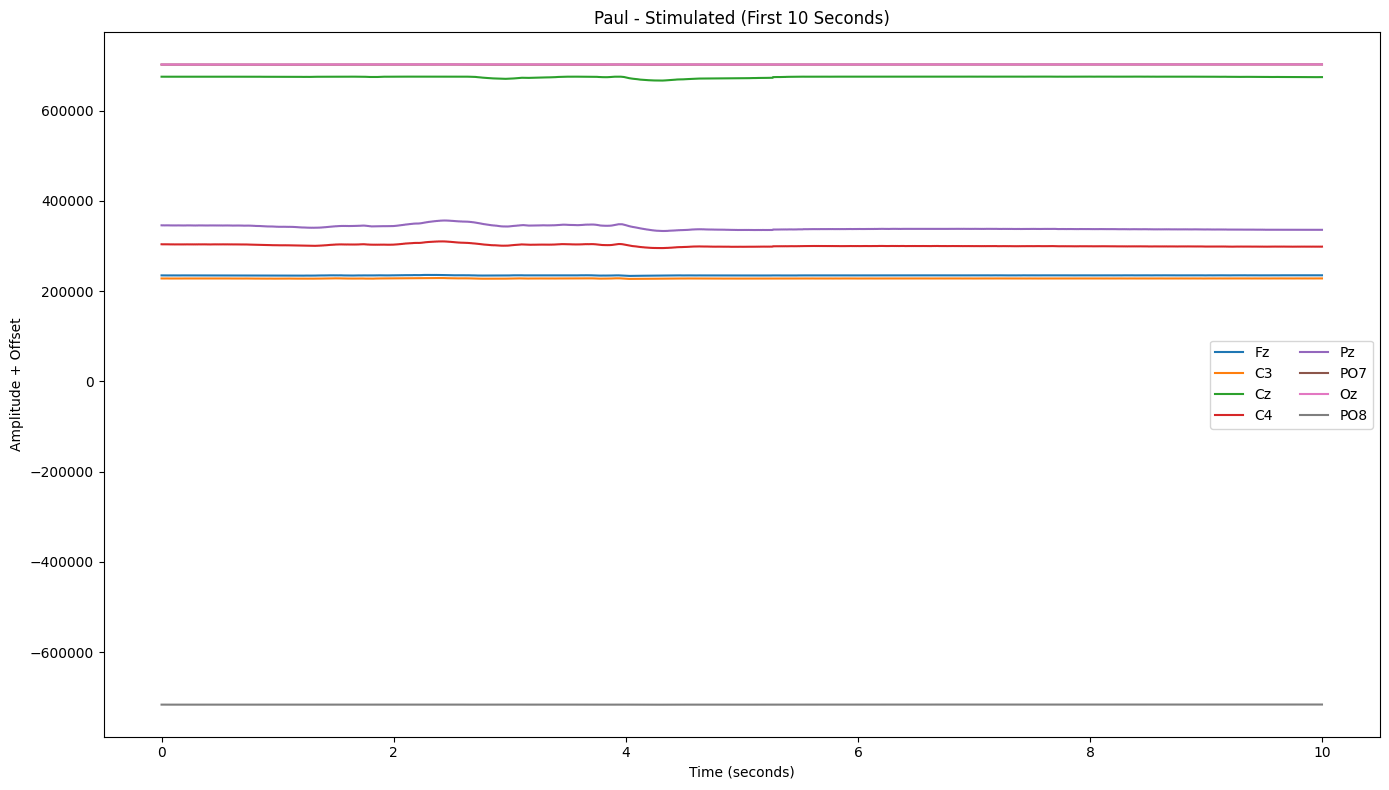

In [ ]:
# Plot a short segment (first 10 seconds) of EEG data for visual inspection
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define parameters for signal processing and plotting (moved from cell n67DOCcTZ40p)
# fs = 250         # Sampling frequency in Hz
# seconds = 10     # Number of seconds to display for plotting
# samples = fs * seconds # Total number of samples for the display window
# spacing = 200    # Vertical spacing for plotting different EEG channels

# # List of EEG channel names to be analyzed and plotted
# channels = ["Fz","C3","Cz","C4","Pz","PO7","Oz","PO8"]

# Define the path to a specific EEG data file for Paul in the 'Stimulated' condition
file_paul = "/content/EEG_data/Paul/Stimulated/trial001_Unicorn_EEG_20260406_161921.csv"

# Read the EEG data file, ignoring comment lines starting with '#'
df_paul = pd.read_csv(file_paul, comment="#")

# Select the first 'samples' (10 seconds) of data for plotting
df_short = df_paul.iloc[:samples]

# Create a time vector for the x-axis
t = np.arange(samples) / fs

# Create a new figure for the plot
plt.figure(figsize=(14,8))

# Plot each channel with a vertical offset for better visualization
for i, ch in enumerate(channels):
    plt.plot(t, df_short[ch] + i*spacing, label=ch)

# Add plot title, labels, and legend
plt.title("Paul - Stimulated (First 10 Seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude + Offset")
plt.legend(ncol=2)
plt.tight_layout() # Adjust layout to prevent labels from overlapping

plt.show() # Display the plot

In [ ]:
# Clean up column names by stripping leading/trailing whitespace
df_paul.columns = df_paul.columns.str.strip()

# Print the cleaned column names to verify the change
print(df_paul.columns)

Index(['timestamp', 'Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'Oz', 'PO8'], dtype='object')


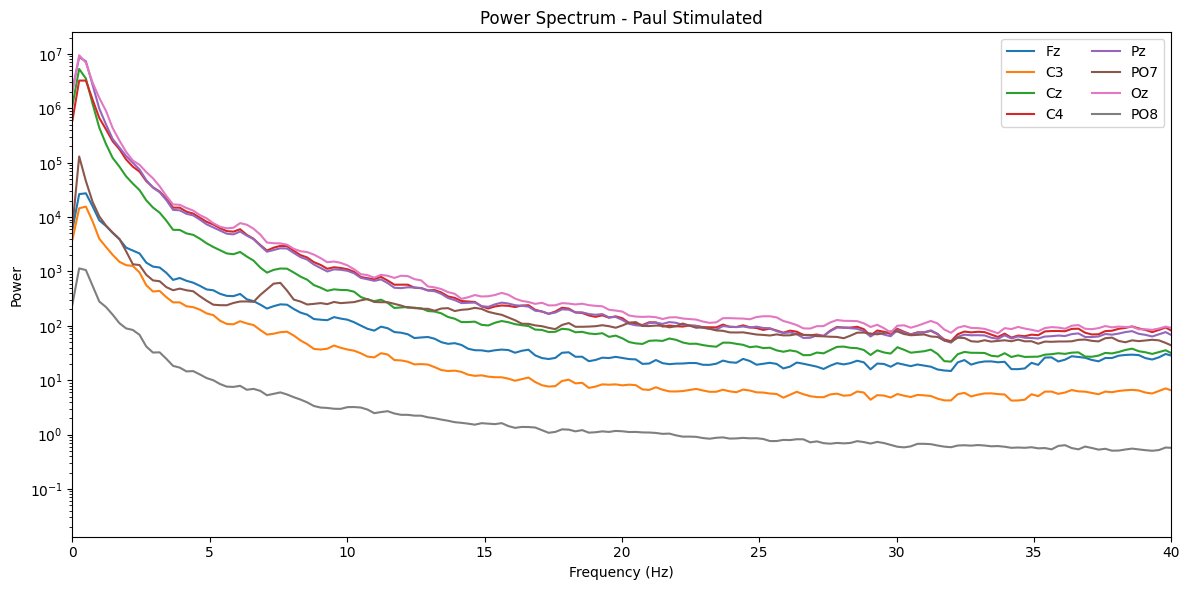

In [ ]:
# Plot the Power Spectral Density (PSD) of EEG channels to visualize frequency components
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

# Sampling frequency in Hz
fs = 250

# Define the path to a specific EEG data file for Paul in the 'Stimulated' condition
file_paul = "/content/EEG_data/Paul/Stimulated/trial001_Unicorn_EEG_20260406_161921.csv"
# Read the EEG data file, ignoring comment lines starting with '#'
df_paul = pd.read_csv(file_paul, comment="#")
# Clean up column names by stripping leading/trailing whitespace
df_paul.columns = df_paul.columns.str.strip()

# List of EEG channel names to be analyzed
channels = ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'Oz', 'PO8']

# Create a new figure for the plot
plt.figure(figsize=(12, 6))

# Iterate through each channel, calculate PSD, and plot it
for ch in channels:
    signal = df_paul[ch].to_numpy()
    # Use Welch's method to estimate the PSD. nperseg is the length of segments for FFT.
    f, pxx = welch(signal, fs=fs, nperseg=1024)
    plt.semilogy(f, pxx, label=ch) # Use semilogy for better visualization of power differences

# Set x-axis limits to focus on relevant EEG frequencies (0-40 Hz)
plt.xlim(0, 40)
plt.title("Power Spectrum - Paul Stimulated")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.legend(ncol=2) # Display legend with two columns
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

In [ ]:
# ============================================================
# CELL 1: Leave-One-Subject-Out (LOSO) splits
# Uses the df_meta you already created earlier
# ============================================================

subjects = sorted(df_meta["subject"].unique())

loso_splits = []

for test_subject in subjects:
    train_df = df_meta[df_meta["subject"] != test_subject].reset_index(drop=True)
    test_df  = df_meta[df_meta["subject"] == test_subject].reset_index(drop=True)

    loso_splits.append({
        "test_subject": test_subject,
        "train_df": train_df,
        "test_df": test_df
    })

print(f"Created {len(loso_splits)} LOSO folds.\n")

for i, split in enumerate(loso_splits, 1):
    print(f"Fold {i}: test subject = {split['test_subject']}")
    print("  Train subjects:", sorted(split["train_df"]["subject"].unique()))
    print("  Test subjects: ", sorted(split["test_df"]["subject"].unique()))
    print("  Train files:", len(split["train_df"]))
    print("  Test files: ", len(split["test_df"]))
    print("-" * 60)

Created 4 LOSO folds.

Fold 1: test subject = Christian
  Train subjects: ['Coop', 'Marinna', 'Paul']
  Test subjects:  ['Christian']
  Train files: 9
  Test files:  3
------------------------------------------------------------
Fold 2: test subject = Coop
  Train subjects: ['Christian', 'Marinna', 'Paul']
  Test subjects:  ['Coop']
  Train files: 9
  Test files:  3
------------------------------------------------------------
Fold 3: test subject = Marinna
  Train subjects: ['Christian', 'Coop', 'Paul']
  Test subjects:  ['Marinna']
  Train files: 9
  Test files:  3
------------------------------------------------------------
Fold 4: test subject = Paul
  Train subjects: ['Christian', 'Coop', 'Marinna']
  Test subjects:  ['Paul']
  Train files: 9
  Test files:  3
------------------------------------------------------------


Fold 1 | Test subject: Christian
X_train shape: (4137, 112)
X_test shape:  (1436, 112)
Polynomial SVM -> Accuracy: 0.2542, Macro F1: 0.2057
RBF SVM        -> Accuracy: 0.3357, Macro F1: 0.1675
Random Forest -> Accuracy: 0.3357, Macro F1: 0.1675
Fold 2 | Test subject: Coop
X_train shape: (4209, 112)
X_test shape:  (1364, 112)
Polynomial SVM -> Accuracy: 0.3365, Macro F1: 0.2000
RBF SVM        -> Accuracy: 0.3512, Macro F1: 0.1733
Random Forest -> Accuracy: 0.4172, Macro F1: 0.2848
Fold 3 | Test subject: Marinna
X_train shape: (4137, 112)
X_test shape:  (1436, 112)
Polynomial SVM -> Accuracy: 0.3377, Macro F1: 0.1779
RBF SVM        -> Accuracy: 0.3357, Macro F1: 0.1675
Random Forest -> Accuracy: 0.3364, Macro F1: 0.2006
Fold 4 | Test subject: Paul
X_train shape: (4236, 112)
X_test shape:  (1337, 112)
Polynomial SVM -> Accuracy: 0.3882, Macro F1: 0.3267
RBF SVM        -> Accuracy: 0.3336, Macro F1: 0.1668
Random Forest -> Accuracy: 0.3695, Macro F1: 0.3602


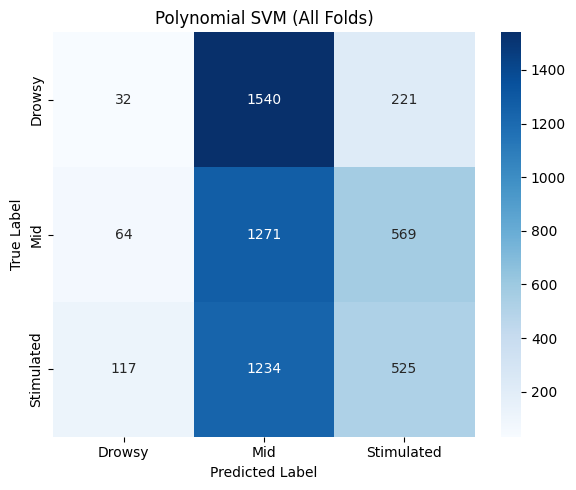

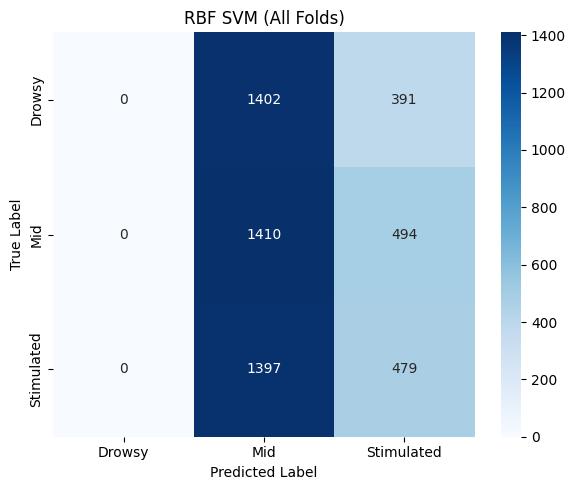


Per-fold LOSO results
   fold test_subject  n_train_windows  n_test_windows  poly_acc  \
0     1    Christian           4137.0          1436.0  0.254178   
1     1    Christian              NaN             NaN  0.254178   
2     2         Coop           4209.0          1364.0  0.336510   
3     2         Coop              NaN             NaN  0.336510   
4     3      Marinna           4137.0          1436.0  0.337744   
5     3      Marinna              NaN             NaN  0.337744   
6     4         Paul           4236.0          1337.0  0.388182   
7     4         Paul              NaN             NaN  0.388182   

   poly_f1_macro   rbf_acc  rbf_f1_macro    rf_acc  rf_f1_macro  
0       0.205681  0.335655      0.167536       NaN          NaN  
1       0.205681  0.335655      0.167536  0.335655     0.167536  
2       0.199985  0.351173      0.173268       NaN          NaN  
3       0.199985  0.351173      0.173268  0.417155     0.284761  
4       0.177866  0.335655      0.167536   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ============================================================
# CELL 2: SVM on LOSO folds (Polynomial + RBF)
# ============================================================

import os
import numpy as np
import pandas as pd
from scipy.signal import welch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Params
# -----------------------------
fs = 250
window_seconds = 4
window_size = fs * window_seconds
step_size = window_size // 2   # 50% overlap

channels = ["Fz","C3","Cz","C4","Pz","PO7","Oz","PO8"]

# -----------------------------
# Functions
# -----------------------------
def safe_read_csv(fpath):
    df = pd.read_csv(fpath, comment="#")
    df.columns = df.columns.str.strip()
    return df

#create a bandpass filter for 2 times the nyquist rate
def bandpass_filter_signal(signal_2d, fs, low=1, high=30, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")

    filtered = filtfilt(b, a, signal_2d, axis=0)

    return filtered

#create the sliding window
#pass in the step size and the window size
#making it a function in case we want to change in the future
def create_windows(signal_2d, window_size, step_size):
    windows = []
    for start in range(0, len(signal_2d) - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal_2d[start:end])
    return np.array(windows)


def compute_subject_stats(meta_df, channels):
    subject_stats = {}

    for subject in meta_df["subject"].unique():
        all_data = []
        subject_files = meta_df[meta_df["subject"] == subject]
        for _, row in subject_files.iterrows():
            df = safe_read_csv(row["filepath"])
            if not all(ch in df.columns for ch in channels):
                continue
            signal = df[channels].to_numpy(dtype=float)
            all_data.append(signal)

        # Concatenate all files for this subject
        all_data = np.vstack(all_data)

        mu = np.mean(all_data, axis=0)
        sigma = np.std(all_data, axis=0) + 1e-8
        subject_stats[subject] = (mu, sigma)

    return subject_stats

#get the bandpower
def bandpower(x, fs, band):
    low, high = band
    freqs, psd = welch(x, fs=fs, nperseg=min(256, len(x)))
    idx = (freqs >= low) & (freqs <= high)
    if np.sum(idx) == 0:
        return 0.0
    return np.trapezoid(psd[idx], freqs[idx])

#extract features
def extract_features(window, fs=250):
    features = []


    #delta in freq 0.5 - 4
    delta = (0.5, 4)
    #theta in freq 4-8
    theta = (4, 8)
    #alpha in freq 8-13
    alpha = (8, 13)
    #beta in freq 13-30
    beta  = (13, 30)

    eps = 1e-12

    for ch in range(window.shape[1]):
        sig_ch = window[:, ch]

        # -------------------------
        # time domain features
        # ----------------------
        mean_val = np.mean(sig_ch)
        std_val = np.std(sig_ch)
        var_val = np.var(sig_ch)

        # -------------------------
        # bandpower features
        # -------------------------
        delta_power = bandpower(sig_ch, fs, delta)
        theta_power = bandpower(sig_ch, fs, theta)
        alpha_power = bandpower(sig_ch, fs, alpha)
        beta_power  = bandpower(sig_ch, fs, beta)

        total_power = delta_power + theta_power + alpha_power + beta_power + eps

        # -------------------------
        # relative bandpower features
        #hopefully these help w/ normilization and generalizing to new subjects
        # -------------------------
        rel_delta = delta_power / total_power
        rel_theta = theta_power / total_power
        rel_alpha = alpha_power / total_power
        rel_beta  = beta_power  / total_power

        # -------------------------
        #ratio features
        #hopefully good for norm
        # -------------------------
        theta_alpha = theta_power / (alpha_power + eps)
        theta_beta  = theta_power / (beta_power + eps)
        alpha_beta  = alpha_power / (beta_power + eps)

        features.extend([
            mean_val,
            std_val,
            var_val,

            delta_power,
            theta_power,
            alpha_power,
            beta_power,

            rel_delta,
            rel_theta,
            rel_alpha,
            rel_beta,

            theta_alpha,
            theta_beta,
            alpha_beta
        ])

    return np.array(features, dtype=float)



def build_window_dataset(meta_df, channels, fs, window_size, step_size, subject_stats=None):
    X, y = [], []

    for _, row in meta_df.iterrows():
        fpath = row["filepath"]
        subject = row["subject"]

        try:
            df = safe_read_csv(fpath)

            # skip if channels missing
            if not all(ch in df.columns for ch in channels):
                print(f"Skipping {fpath} because required channels are missing.")
                continue

            signal_2d = df[channels].to_numpy(dtype=float)
            # Bandpass filter before normalization/windowing
            signal_2d = bandpass_filter_signal(signal_2d, fs, low=0.5, high=40)
            #These lines are before per-subject normalization...
            #signal_2d = (signal_2d - signal_2d.mean(axis=0)) / (signal_2d.std(axis=0) + 1e-8)
            #windows = create_windows(signal_2d, window_size, step_size)

            # norm per subject
            if subject_stats is not None:
                if subject in subject_stats:
                    mu, sigma = subject_stats[subject]
                    signal_2d = (signal_2d - mu) / sigma
                else:
                    mu = signal_2d.mean(axis=0)
                    sigma = signal_2d.std(axis=0) + 1e-8
                    signal_2d = (signal_2d - mu) / sigma
            else:
                signal_2d = (signal_2d - signal_2d.mean(axis=0)) / (signal_2d.std(axis=0) + 1e-8)

            #create windows after normalization
            windows = create_windows(signal_2d, window_size, step_size)

            for w in windows:
                X.append(extract_features(w, fs=fs))
                y.append(row["label"])

        except Exception as e:
            print(f"Error reading {fpath}: {e}")

    return np.array(X), np.array(y)

#we should plot confusion matrix for eval
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    #blue color is best one
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Drowsy", "Mid", "Stimulated"],
    yticklabels=["Drowsy", "Mid", "Stimulated"])

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Run LOSO SVM
# -----------------------------
results = []

all_true_poly = []
all_pred_poly = []

all_true_rbf = []
all_pred_rbf = []

all_true_rf = []
all_pred_rf = []

for fold_idx, split in enumerate(loso_splits, start=1):
    test_subject = split["test_subject"]
    train_df = split["train_df"]
    test_df = split["test_df"]

    print("=" * 70)
    print(f"Fold {fold_idx} | Test subject: {test_subject}")

     # Compute stats just on training subjects
    subject_stats = compute_subject_stats(train_df, channels)

    # Pass stats into dataset builder
    X_train, y_train = build_window_dataset(
        train_df, channels, fs, window_size, step_size,
        subject_stats=subject_stats)

    X_test, y_test = build_window_dataset(
        test_df, channels, fs, window_size, step_size,
        subject_stats=subject_stats)

#These are from before per-subject normalization...
    #X_train, y_train = build_window_dataset(train_df, channels, fs, window_size, step_size)
    #X_test, y_test   = build_window_dataset(test_df, channels, fs, window_size, step_size)

    print("X_train shape:", X_train.shape)
    print("X_test shape: ", X_test.shape)

    # Polynomial SVM
    poly_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="poly", degree=3, C=1.0, gamma="scale", coef0=1.0))
    ])

    poly_clf.fit(X_train, y_train)
    y_pred_poly = poly_clf.predict(X_test)

    poly_acc = accuracy_score(y_test, y_pred_poly)
    poly_f1  = f1_score(y_test, y_pred_poly, average="macro")

    print(f"Polynomial SVM -> Accuracy: {poly_acc:.4f}, Macro F1: {poly_f1:.4f}")

    # RBF SVM
    rbf_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ])

    rbf_clf.fit(X_train, y_train)
    y_pred_rbf = rbf_clf.predict(X_test)

    rbf_acc = accuracy_score(y_test, y_pred_rbf)
    rbf_f1  = f1_score(y_test, y_pred_rbf, average="macro")

    print(f"RBF SVM        -> Accuracy: {rbf_acc:.4f}, Macro F1: {rbf_f1:.4f}")

    results.append({
        "fold": fold_idx,
        "test_subject": test_subject,
        "n_train_windows": len(X_train),
        "n_test_windows": len(X_test),
        "poly_acc": poly_acc,
        "poly_f1_macro": poly_f1,
        "rbf_acc": rbf_acc,
        "rbf_f1_macro": rbf_f1
    })

    all_true_poly.extend(y_test.tolist())
    all_pred_poly.extend(y_pred_poly.tolist())

    all_true_rbf.extend(y_test.tolist())
    all_pred_rbf.extend(y_pred_rbf.tolist())


    #------------- RANDOM FOREST --------------------

    #use skilearn library for RF
    from sklearn.ensemble import RandomForestClassifier

    #hyperparams that were rec was baseline n_estimators=100 and max_depth=None
    rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=None, random_state=42)

    rf_clf.fit(X_train, y_train)
    y_pred_rf = rf_clf.predict(X_test)

    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_f1  = f1_score(y_test, y_pred_rf, average="macro")

    print(f"Random Forest -> Accuracy: {rf_acc:.4f}, Macro F1: {rf_f1:.4f}")
    results.append({
    "fold": fold_idx,
    "test_subject": test_subject,

    "poly_acc": poly_acc,
    "poly_f1_macro": poly_f1,

    "rbf_acc": rbf_acc,
    "rbf_f1_macro": rbf_f1,

    "rf_acc": rf_acc,
    "rf_f1_macro": rf_f1
    })
    all_true_rf.extend(y_test.tolist())
    all_pred_rf.extend(y_pred_rf.tolist())

# -----------------------------
#Overall Results to get a nice printout
# -----------------------------
plot_confusion_matrix(all_true_poly, all_pred_poly, "Polynomial SVM (All Folds)")
plot_confusion_matrix(all_true_rbf, all_pred_rbf, "RBF SVM (All Folds)")
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("Per-fold LOSO results")
print(results_df)

print("\nMean across folds")
print(results_df[["poly_acc", "poly_f1_macro", "rbf_acc", "rbf_f1_macro"]].mean())

print("\n" + "=" * 70)
print("Overall pooled results")

print("\nPolynomial SVM")
print("Accuracy:", accuracy_score(all_true_poly, all_pred_poly))
print("Macro F1:", f1_score(all_true_poly, all_pred_poly, average="macro"))
print("Confusion Matrix:")
print(confusion_matrix(all_true_poly, all_pred_poly))
print(classification_report(all_true_poly, all_pred_poly, digits=4))

print("\nRBF SVM")
print("Accuracy:", accuracy_score(all_true_rbf, all_pred_rbf))
print("Macro F1:", f1_score(all_true_rbf, all_pred_rbf, average="macro"))
print("Confusion Matrix:")
print(confusion_matrix(all_true_rbf, all_pred_rbf))
print(classification_report(all_true_rbf, all_pred_rbf, digits=4))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(all_true_rf, all_pred_rf))
print("Macro F1:", f1_score(all_true_rf, all_pred_rf, average="macro"))
print("Confusion Matrix:")
print(confusion_matrix(all_true_rf, all_pred_rf))
print(classification_report(all_true_rf, all_pred_rf, digits=4))

In [ ]:
# ============================================================
# normalized psd by subject so we can see if this data is useable
# One subplot per subject, same scale across plots
# Uses relative power so shapes are comparable across subjects
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 250
channels = ["Fz","C3","Cz","C4","Pz","PO7","Oz","PO8"]

class_order = ["stimulated", "mid", "drowsy"]
class_colors = {
    "stimulated": "red",
    "mid": "blue",
    "drowsy": "green"
}

fmin, fmax = 0.5, 40

subject_class_psds = {}

for _, row in df_meta.iterrows():
    fpath = row["filepath"]
    subject = row["subject"]
    class_name = row["class_name"]

    try:
        df = pd.read_csv(fpath, comment="#")
        df.columns = df.columns.str.strip()

        if not all(ch in df.columns for ch in channels):
            continue

        signal = df[channels].to_numpy()

        # average PSD across channels
        psds = []
        freqs_ref = None

        for ch_idx in range(len(channels)):
            f, pxx = welch(signal[:, ch_idx], fs=fs, nperseg=1024)
            if freqs_ref is None:
                freqs_ref = f
            psds.append(pxx)

        mean_psd = np.mean(psds, axis=0)

        # keep only desired frequency band
        band_mask = (freqs_ref >= fmin) & (freqs_ref <= fmax)
        freqs_band = freqs_ref[band_mask]
        psd_band = mean_psd[band_mask]

        # normalize to relative power
        total_power = np.trapezoid(psd_band, freqs_band)
        if total_power > 0:
            psd_norm = psd_band / total_power
        else:
            psd_norm = psd_band

        if subject not in subject_class_psds:
            subject_class_psds[subject] = {}
        if class_name not in subject_class_psds[subject]:
            subject_class_psds[subject][class_name] = []

        subject_class_psds[subject][class_name].append(psd_norm)

    except Exception as e:
        print(f"Error reading {fpath}: {e}")

subjects = sorted(subject_class_psds.keys())
n_subjects = len(subjects)

fig, axes = plt.subplots(1, n_subjects, figsize=(6 * n_subjects, 5), sharex=True, sharey=True)
if n_subjects == 1:
    axes = [axes]

global_ymax = 0

# first pass: compute class averages and global ymax
subject_means = {}
for subject in subjects:
    subject_means[subject] = {}
    for class_name in class_order:
        if class_name in subject_class_psds[subject]:
            class_psd_mean = np.mean(subject_class_psds[subject][class_name], axis=0)
            subject_means[subject][class_name] = class_psd_mean
            global_ymax = max(global_ymax, np.max(class_psd_mean))

# second pass: plot
for ax, subject in zip(axes, subjects):
    for class_name in class_order:
        if class_name in subject_means[subject]:
            ax.plot(
                freqs_band,
                subject_means[subject][class_name],
                label=class_name,
                color=class_colors[class_name],
                linewidth=2
            )

    ax.set_title(subject)
    ax.set_xlim(fmin, fmax)
    ax.set_ylim(0, global_ymax * 1.05)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Relative Power")
    ax.grid(True)
    ax.legend()

plt.suptitle("Normalized PSD by Subject (same scale across plots)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Boxplots of bandpower features by class and by subject
# One row = one trial/file
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 250
channels = ["Fz","C3","Cz","C4","Pz","PO7","Oz","PO8"]

# -----------------------------
# Helper functions
# -----------------------------
def safe_read_csv(fpath):
    df = pd.read_csv(fpath, comment="#")
    df.columns = df.columns.str.strip()
    return df

def bandpower(x, fs, band, nperseg=1024):
    low, high = band
    f, pxx = welch(x, fs=fs, nperseg=min(nperseg, len(x)))
    mask = (f >= low) & (f <= high)
    if np.sum(mask) == 0:
        return 0.0
    return np.trapezoid(pxx[mask], f[mask])

# EEG bands
delta_band = (0.5, 4)
theta_band = (4, 8)
alpha_band = (8, 13)
beta_band  = (13, 30)

eps = 1e-12   # prevents divide-by-zero in ratios

# -----------------------------
# Build per-file feature table
# -----------------------------
rows = []

for _, row in df_meta.iterrows():
    fpath = row["filepath"]
    subject = row["subject"]
    class_name = row["class_name"]
    filename = row["filename"]

    try:
        df = safe_read_csv(fpath)

        if not all(ch in df.columns for ch in channels):
            print(f"Skipping {filename}: missing required channels")
            continue

        signal = df[channels].to_numpy()

        delta_vals = []
        theta_vals = []
        alpha_vals = []
        beta_vals  = []

        # compute bandpower per channel
        for ch_idx in range(signal.shape[1]):
            x = signal[:, ch_idx]

            delta_vals.append(bandpower(x, fs, delta_band))
            theta_vals.append(bandpower(x, fs, theta_band))
            alpha_vals.append(bandpower(x, fs, alpha_band))
            beta_vals.append(bandpower(x, fs, beta_band))

        # average across channels for one value per file
        delta_power = np.mean(delta_vals)
        theta_power = np.mean(theta_vals)
        alpha_power = np.mean(alpha_vals)
        beta_power  = np.mean(beta_vals)

        rows.append({
            "subject": subject,
            "class_name": class_name,
            "filename": filename,
            "delta": delta_power,
            "theta": theta_power,
            "alpha": alpha_power,
            "beta": beta_power,
            "theta_alpha": theta_power / (alpha_power + eps),
            "theta_beta": theta_power / (beta_power + eps),
            "alpha_beta": alpha_power / (beta_power + eps),
        })

    except Exception as e:
        print(f"Error reading {fpath}: {e}")

feature_df = pd.DataFrame(rows)

print("Per-file bandpower feature table:")
print(feature_df.head())
print("\nCounts by subject/class:")
print(feature_df.groupby(["subject", "class_name"]).size())

# -----------------------------
# Plot settings
# -----------------------------
features_to_plot = ["delta", "theta", "alpha", "beta", "theta_alpha", "theta_beta", "alpha_beta"]
feature_titles = {
    "delta": "Delta Power",
    "theta": "Theta Power",
    "alpha": "Alpha Power",
    "beta": "Beta Power",
    "theta_alpha": "Theta / Alpha",
    "theta_beta": "Theta / Beta",
    "alpha_beta": "Alpha / Beta",
}

class_order = ["stimulated", "mid", "drowsy"]
subject_order = sorted(feature_df["subject"].unique())

# -----------------------------
# Boxplots grouped by class
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    data = [feature_df.loc[feature_df["class_name"] == cls, feat].dropna().values for cls in class_order]

    ax.boxplot(data, tick_labels=class_order)
    ax.set_title(feature_titles[feat])
    ax.set_xlabel("Class")
    ax.set_ylabel("Value")
    ax.grid(True, axis="y", alpha=0.3)

# hide unused subplot
for j in range(len(features_to_plot), len(axes)):
    axes[j].axis("off")

plt.suptitle("Bandpower Features Grouped by Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------
# Boxplots grouped by subject
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    data = [feature_df.loc[feature_df["subject"] == subj, feat].dropna().values for subj in subject_order]

    ax.boxplot(data, tick_labels=subject_order)
    ax.set_title(feature_titles[feat])
    ax.set_xlabel("Subject")
    ax.set_ylabel("Value")
    ax.grid(True, axis="y", alpha=0.3)

# hide unused subplot
for j in range(len(features_to_plot), len(axes)):
    axes[j].axis("off")

plt.suptitle("Bandpower Features Grouped by Subject", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TIME-BASED 80/20 SPLIT (Coop, Paul, Christian only) WITH PURGE GAP
# ============================================================

import numpy as np
import pandas as pd
from scipy.signal import welch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.signal import butter, filtfilt

# -----------------------------
# Settings
# -----------------------------
fs = 250
window_seconds = 4
window_size = fs * window_seconds
step_size = window_size // 2

purge_seconds = 2   #purge gap (adjustable)
purge_samples = int(purge_seconds * fs)

channels = ["Fz","C3","Cz","C4","Pz","PO7","Oz","PO8"]

# -----------------------------
# Helpers (same as before)
# -----------------------------
def safe_read_csv(fpath):
    df = pd.read_csv(fpath, comment="#")
    df.columns = df.columns.str.strip()
    return df

def create_windows(signal_2d, window_size, step_size):
    windows = []
    for start in range(0, len(signal_2d) - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal_2d[start:end])
    return np.array(windows)

def bandpower(x, fs, band):
    low, high = band
    f, pxx = welch(x, fs=fs, nperseg=min(256, len(x)))
    mask = (f >= low) & (f <= high)
    if np.sum(mask) == 0:
        return 0.0
    return np.trapezoid(pxx[mask], f[mask])

def extract_features(window, fs=250):
    features = []

    delta = (0.5, 4)
    theta = (4, 8)
    alpha = (8, 13)
    beta  = (13, 30)

    eps = 1e-12

    for ch in range(window.shape[1]):
        sig_ch = window[:, ch]

        # -------------------------
        # Time-domain features
        # -------------------------
        mean_val = np.mean(sig_ch)
        std_val = np.std(sig_ch)
        var_val = np.var(sig_ch)

        # -------------------------
        # Bandpower features
        # -------------------------
        delta_power = bandpower(sig_ch, fs, delta)
        theta_power = bandpower(sig_ch, fs, theta)
        alpha_power = bandpower(sig_ch, fs, alpha)
        beta_power  = bandpower(sig_ch, fs, beta)

        total_power = delta_power + theta_power + alpha_power + beta_power + eps

        # -------------------------
        # Relative bandpower features
        # -------------------------
        rel_delta = delta_power / total_power
        rel_theta = theta_power / total_power
        rel_alpha = alpha_power / total_power
        rel_beta  = beta_power  / total_power

        # -------------------------
        # Ratio features
        # -------------------------
        theta_alpha = theta_power / (alpha_power + eps)
        theta_beta  = theta_power / (beta_power + eps)
        alpha_beta  = alpha_power / (beta_power + eps)

        features.extend([
            mean_val,
            std_val,
            var_val,

            delta_power,
            theta_power,
            alpha_power,
            beta_power,

            rel_delta,
            rel_theta,
            rel_alpha,
            rel_beta,

            theta_alpha,
            theta_beta,
            alpha_beta
        ])

    return np.array(features, dtype=float)

# -----------------------------
# Filter only Coop, Paul, Christian
# -----------------------------
df_subset = df_meta[df_meta["subject"].isin(["Coop", "Paul", "Christian"])].reset_index(drop=True)

X_train_all, y_train_all = [], []
X_test_all, y_test_all = [], []

# -----------------------------
# Process each file independently (NO LEAKAGE)
# -----------------------------
for _, row in df_subset.iterrows():
    fpath = row["filepath"]
    label = row["label"]

    try:
        df = safe_read_csv(fpath)

        if not all(ch in df.columns for ch in channels):
            continue

        signal = df[channels].to_numpy()
        #Bandpass filter
        signal = bandpass_filter_signal(signal, fs, low=0.5, high=40)
        N = len(signal)

        # --- time split ---
        split_idx = int(0.8 * N)

        # apply purge gap
        train_signal = signal[:split_idx - purge_samples]
        test_signal  = signal[split_idx + purge_samples:]

        # skip if too small after purge
        if len(train_signal) < window_size or len(test_signal) < window_size:
            continue

        # create windows AFTER split
        train_windows = create_windows(train_signal, window_size, step_size)
        test_windows  = create_windows(test_signal, window_size, step_size)

        # extract features
        for w in train_windows:
            X_train_all.append(extract_features(w))
            y_train_all.append(label)

        for w in test_windows:
            X_test_all.append(extract_features(w))
            y_test_all.append(label)

    except Exception as e:
        print(f"Error: {e}")

X_train_all = np.array(X_train_all)
y_train_all = np.array(y_train_all)

X_test_all = np.array(X_test_all)
y_test_all = np.array(y_test_all)

print("Train shape:", X_train_all.shape)
print("Test shape: ", X_test_all.shape)

# -----------------------------
# SVM Models
# -----------------------------
poly_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="poly", degree=3, C=1.0, gamma="scale", coef0=1.0))
])

rbf_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# -----------------------------
# Train + Evaluate
# -----------------------------
poly_clf.fit(X_train_all, y_train_all)
y_pred_poly = poly_clf.predict(X_test_all)

rbf_clf.fit(X_train_all, y_train_all)
y_pred_rbf = rbf_clf.predict(X_test_all)

print("\n================ TIME SPLIT RESULTS ================\n")

print("Polynomial SVM")
print("Accuracy:", accuracy_score(y_test_all, y_pred_poly))
print("Macro F1:", f1_score(y_test_all, y_pred_poly, average="macro"))
print(classification_report(y_test_all, y_pred_poly, digits=4))

print("\nRBF SVM")
print("Accuracy:", accuracy_score(y_test_all, y_pred_rbf))
print("Macro F1:", f1_score(y_test_all, y_pred_rbf, average="macro"))
print(classification_report(y_test_all, y_pred_rbf, digits=4))

In [ ]:
# ============================================================
# Boxplots of bandpower features by class and by subject
# 1) grouped by class
# 2) grouped by file
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 250
channels = ["Fz","C3","Cz","C4","Pz","PO7","Oz","PO8"]

# -----------------------------
# Helpers
# -----------------------------
def safe_read_csv(fpath):
    df = pd.read_csv(fpath, comment="#")
    df.columns = df.columns.str.strip()
    return df

def bandpower(x, fs, band, nperseg=1024):
    low, high = band
    f, pxx = welch(x, fs=fs, nperseg=min(nperseg, len(x)))
    mask = (f >= low) & (f <= high)
    if np.sum(mask) == 0:
        return 0.0
    return np.trapezoid(pxx[mask], f[mask])

delta_band = (0.5, 4)
theta_band = (4, 8)
alpha_band = (8, 13)
beta_band  = (13, 30)

eps = 1e-12

# -----------------------------
# Build per-file feature table for all subjects
# -----------------------------
rows = []

for _, row in df_meta.iterrows(): # Iterate over the full metadata DataFrame
    fpath = row["filepath"]
    subject = row["subject"]
    class_name = row["class_name"]
    filename = row["filename"]

    try:
        df = safe_read_csv(fpath)

        if not all(ch in df.columns for ch in channels):
            print(f"Skipping {filename}: missing channels")
            continue

        signal = df[channels].to_numpy(dtype=float)

        # compute per-channel bandpowers so boxplots have multiple points
        for ch_idx, ch_name in enumerate(channels):
            x = signal[:, ch_idx]

            delta = bandpower(x, fs, delta_band)
            theta = bandpower(x, fs, theta_band)
            alpha = bandpower(x, fs, alpha_band)
            beta  = bandpower(x, fs, beta_band)

            rows.append({
                "subject": subject,
                "class_name": class_name,
                "filename": filename,
                "channel": ch_name,
                "delta": delta,
                "theta": theta,
                "alpha": alpha,
                "beta": beta,
                "theta_alpha": theta / (alpha + eps),
                "theta_beta": theta / (beta + eps),
                "alpha_beta": alpha / (beta + eps),
            })

    except Exception as e:
        print(f"Error reading {filename}: {e}")

all_feat_df = pd.DataFrame(rows) # Rename to all_feat_df

print("Feature table for all subjects:")
print(all_feat_df.head())
print("\nCounts by subject/class:")
print(all_feat_df.groupby(["subject", "class_name"]).size())

# -----------------------------
# Plot settings
# -----------------------------
features_to_plot = ["delta", "theta", "alpha", "beta", "theta_alpha", "theta_beta", "alpha_beta"]
feature_titles = {
    "delta": "Delta Power",
    "theta": "Theta Power",
    "alpha": "Alpha Power",
    "beta": "Beta Power",
    "theta_alpha": "Theta / Alpha",
    "theta_beta": "Theta / Beta",
    "alpha_beta": "Alpha / Beta",
}

class_order = ["stimulated", "mid", "drowsy"]
subject_order = sorted(all_feat_df["subject"].unique())

# -----------------------------
# Figure 1: grouped by class (for all subjects combined)
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    data = [
        all_feat_df.loc[all_feat_df["class_name"] == cls, feat].dropna().values
        for cls in class_order
        if cls in all_feat_df["class_name"].unique()
    ]
    labels = [cls for cls in class_order if cls in all_feat_df["class_name"].unique()]

    ax.boxplot(data, tick_labels=labels)
    ax.set_title(feature_titles[feat])
    ax.set_xlabel("Class")
    ax.set_ylabel("Value")
    ax.grid(True, axis="y", alpha=0.3)

for j in range(len(features_to_plot), len(axes)):
    axes[j].axis("off")

plt.suptitle("All Subjects: Bandpower Features Grouped by Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------
# Figure 2: grouped by subject (per feature)
# -----------------------------
# Adjusting figure size to accommodate more subplots if needed, or keeping it for now
fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(18, 5 * len(features_to_plot)))
if len(features_to_plot) == 1:
    axes = [axes]

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    data = [
        all_feat_df.loc[all_feat_df["subject"] == subj, feat].dropna().values
        for subj in subject_order
    ]

    ax.boxplot(data, tick_labels=subject_order)
    ax.set_title(feature_titles[feat])
    ax.set_xlabel("Subject")
    ax.set_ylabel("Value")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("All Subjects: Bandpower Features Grouped by Subject", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Save Trained Models

I'll save the `poly_clf` and `rbf_clf` models from the time-based 80/20 split (`sLrlsqXQ5cms` cell) using `joblib`. These models include the `StandardScaler` within their pipelines, so feature scaling will be automatically applied when they are loaded and used for prediction.

In [ ]:
import joblib
import os

# Define paths for saving the models
model_dir = "/content/saved_models"
os.makedirs(model_dir, exist_ok=True)

poly_model_path = os.path.join(model_dir, "poly_svm_time_split.joblib")
rbf_model_path = os.path.join(model_dir, "rbf_svm_time_split.joblib")
rf_model_path = os.path.join(model_dir, "rf_model.joblib")

# Save the models
joblib.dump(poly_clf, poly_model_path)
joblib.dump(rbf_clf, rbf_model_path)
joblib.dump(rf_clf, rf_model_path)

print(f"Polynomial SVM model saved to: {poly_model_path}")
print(f"RBF SVM model saved to: {rbf_model_path}")

# You can verify the content of the directory:
!ls {model_dir}

Polynomial SVM model saved to: /content/saved_models/poly_svm_time_split.joblib
RBF SVM model saved to: /content/saved_models/rbf_svm_time_split.joblib
poly_svm_time_split.joblib  rbf_svm_time_split.joblib  rf_model.joblib


In [ ]:
from google.colab import files

# Download the Polynomial SVM model
files.download("/content/saved_models/poly_svm_time_split.joblib")

# Download the RBF SVM model
files.download("/content/saved_models/rbf_svm_time_split.joblib")

#Download random forest model
files.download("/content/saved_models/rf_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import joblib
import os

# Create export folder (change if you want)
save_dir = "/content/export_for_realtime"
os.makedirs(save_dir, exist_ok=True)

# --- Save test data (features + labels) ---
np.save(os.path.join(save_dir, "X_test_all.npy"), X_test_all)
np.save(os.path.join(save_dir, "y_test_all.npy"), y_test_all)

# --- Save trained model (pipeline already includes scaler) ---
joblib.dump(poly_clf, os.path.join(save_dir, "poly_svm_time_split.joblib"))

print("Saved everything to:", save_dir)

In [ ]:
from google.colab import files

files.download("/content/export_for_realtime/X_test_all.npy")
files.download("/content/export_for_realtime/y_test_all.npy")

### Real-time Classification Script

Below is a Python script that simulates real-time classification. You can copy this code and run it in a separate Python file outside of this notebook.

**How it works:**
1.  **Loads a Model:** It loads one of the `.joblib` models you just saved (e.g., `poly_svm_time_split.joblib`).
2.  **Feature Extraction:** It includes the necessary helper functions (`safe_read_csv`, `create_windows`, `bandpower`, `extract_features`) to process raw EEG data into the features the model expects.
3.  **Simulates Data:** For demonstration, it iterates through a small portion of the `X_test_all` dataset (which represents processed EEG windows). In a real application, this would be live EEG data coming from a sensor.
4.  **Classifies:** For each simulated EEG window, it predicts the mental state (stimulated, mid, drowsy).
5.  **Visual Feedback:** It prints a "button" status (Bright, Dim, Dark) corresponding to the predicted mental state. You can adapt this print statement to control an actual GUI element or hardware.

**To use it:**
1.  Make sure the `poly_svm_time_split.joblib` (or `rbf_svm_time_split.joblib`) file is accessible from where you run this script. You might need to adjust `loaded_model_path`.
2.  Make sure you have `joblib`, `numpy`, `pandas`, and `scipy` installed (`pip install joblib numpy pandas scipy`).
3.  Run the script from your terminal: `python your_script_name.py`.

In [ ]:
import joblib
import numpy as np
import pandas as pd
from scipy.signal import welch
import time
import os

# --- Configuration --- #
# Set the path to the loaded model. Adjust if running in a different environment.
# For this example, we assume the script is run from a location where `saved_models` is accessible.
# If you run this script directly from Colab, you might need to adjust to /content/saved_models/
loaded_model_path = "/content/saved_models/poly_svm_time_split.joblib"

# If you want to test with the RBF model instead:
# loaded_model_path = "/content/saved_models/rbf_svm_time_split.joblib"

# The actual test data (X_test_all) generated in the notebook for simulation
# In a real application, this would be live EEG data.
simulated_eeg_windows = X_test_all # X_test_all should be available from the notebook's global scope
simulated_labels = y_test_all # For comparing against ground truth

# Mapping for labels to mental states and button states
label_to_state = {
    2: "stimulated", # Bright
    1: "mid",        # Dim
    0: "drowsy"      # Dark
}

state_to_button = {
    "stimulated": "BRIGHT ☀️",
    "mid":        "DIM 💡",
    "drowsy":     "DARK ⚫"
}

# --- Feature Extraction Helpers (copied from previous cells) --- #
fs = 250
channels = ["Fz","C3","Cz","C4","Pz","PO7","Oz","PO8"]

def bandpower(x, fs, band):
    low, high = band
    freqs, psd = welch(x, fs=fs, nperseg=min(256, len(x)))
    idx = (freqs >= low) & (freqs <= high)
    if np.sum(idx) == 0:
        return 0.0
    return np.trapz(psd[idx], freqs[idx])

def extract_features(window, fs=250):
    features = []
    theta = (4, 8)
    alpha = (8, 13)
    beta  = (13, 30)

    for ch in range(window.shape[1]):
        sig_ch = window[:, ch]

        # time-domain
        features.append(np.mean(sig_ch))
        features.append(np.std(sig_ch))
        features.append(np.var(sig_ch))

        # frequency-domain
        features.append(bandpower(sig_ch, fs, theta))
        features.append(bandpower(sig_ch, fs, alpha))
        features.append(bandpower(sig_ch, fs, beta))

    return np.array(features, dtype=float)

# Note: The `create_windows` and `safe_read_csv` functions are not directly needed
# here because we are simulating with already prepared `simulated_eeg_windows`.
# In a true real-time scenario, you would have an input function that reads
# raw EEG data and creates windows from it before passing to `extract_features`.

# --- Main Real-time Simulation Loop --- #
def run_realtime_classification(model_path, data_windows, ground_truth_labels=None, interval_seconds=0.1):
    print(f"\nLoading model from: {model_path}")
    try:
        model = joblib.load(model_path)
        print("Model loaded successfully!")
    except FileNotFoundError:
        print(f"Error: Model file not found at {model_path}. Please ensure the path is correct.")
        return
    except Exception as e:
        print(f"Error loading model: {e}")
        return

    print("\nStarting real-time classification simulation...")
    print("Press Ctrl+C to stop.")

    num_correct = 0
    total_predictions = 0

    try:
        for i, window_features in enumerate(data_windows):
            # Simulate receiving a new EEG data window
            # In a real application, `window_features` would be derived from live EEG stream
            # E.g., `raw_eeg_data = get_live_eeg_data()`
            # `window_features = extract_features(raw_eeg_data)`

            # Predict the class for this window
            # The model pipeline handles scaling automatically
            predicted_label = model.predict(window_features.reshape(1, -1))[0]

            # Get mental state and button state
            predicted_state = label_to_state.get(predicted_label, "unknown")
            button_status = state_to_button.get(predicted_state, "UNKNOWN ?")

            output_str = f"Prediction {i+1}: Label={predicted_label} ({predicted_state}), Button={button_status}"

            if ground_truth_labels is not None:
                true_label = ground_truth_labels[i]
                true_state = label_to_state.get(true_label, "unknown")
                output_str += f" (True: {true_label} {true_state})"
                if predicted_label == true_label:
                    num_correct += 1
                total_predictions += 1

            print(output_str)

            time.sleep(interval_seconds) # Simulate processing time or data acquisition rate

    except KeyboardInterrupt:
        print("\nSimulation stopped by user.")

    if total_predictions > 0:
        accuracy = num_correct / total_predictions
        print(f"\nSimulation Summary: Processed {total_predictions} windows, Accuracy: {accuracy:.2f}")


# Ensure X_test_all and y_test_all are available for simulation.
# If running this script as a standalone file, you would need to regenerate
# these from your raw data using the same feature extraction logic.
if 'simulated_eeg_windows' in locals() and len(simulated_eeg_windows) > 0:
    # Run the simulation
    run_realtime_classification(
        model_path=loaded_model_path,
        data_windows=simulated_eeg_windows,
        ground_truth_labels=simulated_labels,
        interval_seconds=0.01 # Faster for demonstration
    )
else:
    print("Error: `simulated_eeg_windows` (X_test_all) not found. Please ensure cell `sLrlsqXQ5cms` was run and its output variables are available, or manually load/generate test features.")
    # Example of how you would load data if running standalone:
    # X_test_all_loaded = np.load("path/to/your/X_test_all.npy")
    # y_test_all_loaded = np.load("path/to/your/y_test_all.npy")
    # run_realtime_classification(model_path, X_test_all_loaded, y_test_all_loaded)